In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45
from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
    get_parameter_save_callback
)
from logger import Logger


In [ ]:
import flax.linen as nn
import flax.serialization
import jax.numpy as jnp
import numpy as np
import optax
import jax
from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
N = 20
alpha = 1
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)


def get_model():
    return nk.models.RBM(
        alpha=alpha,
        param_dtype=complex,
    )


def get_parity_state(n_samples):

    # sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    sampler = nk.sampler.MetropolisSampler(hilbert, LocalDoubleFlipRule(), n_chains=n_samples)
    model = get_model()
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    print("number of parameters", vstate.n_parameters)
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    # Create the driver
    graph = nk.graph.Chain(N, pbc=False)
    # Converge to Parity space.
    Pz = nk.operator.PauliStringsJax(hilbert, "Z" * N, -1.0)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    hamiltonian = 1.0 / (N - 1) * Hxx + Pz
    diag_shift = 1e-6
    optimizer = optax.sgd(
        learning_rate=optax.schedules.linear_schedule(
            0.05, end_value=1e-3, transition_steps=1000
        )
    )
    gs = nk.driver.VMC_SR(
        hamiltonian, optimizer, diag_shift=diag_shift, variational_state=vstate
    )
    gs.run(
        n_iter=10000,
        callback=(lambda x, l, d: d._loss_stats.mean > -2.0 + 1e-3),
    )
    loss = gs._loss_stats.mean
    assert loss < -2.0 + 1e-2, "not converged"
    print("Optimization succesful")
    return vstate.parameters.copy()


def get_vstate(n_samples):
    seed = 300
    model = get_model()
    sampler = nk.sampler.MetropolisSampler(hilbert, LocalDoubleFlipRule(), n_chains=n_samples)
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=seed, sampler_seed=seed
    )
    return vstate


var_path = f"./data/TFIM_{N}_parity/"
if not os.path.exists(var_path + "params.mpack"):
    os.makedirs(var_path, exist_ok=True)
    parity_parameters = get_parity_state(2**13)
    binary_data = flax.serialization.to_bytes(parity_parameters)
    with open(var_path + "params.mpack", "wb") as outfile:
        outfile.write(binary_data)
    print("Saved parameters")
else:
    with open(var_path + "params.mpack", "rb") as infile:
        binary_data = infile.read()
        vstate = get_vstate(2**10)
        parity_parameters = flax.serialization.from_bytes(
            vstate.parameters, binary_data
        )
        parity_parameters = jax.tree.map(
            lambda x: jnp.array(x, complex), parity_parameters
        )
    print("Loaded parameters")
vstate = get_vstate(2**10)
vstate.parameters = parity_parameters.copy()
# print(vstate.to_array())
sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
print(vstate.expect(sigma_z))


# print(hilbert.all_states)

Loaded parameters
0.9980+0.0000j ± 0.0020 [σ²=3.9e-03]
0.5339925130208333


# Prepare Hamiltonian

In [125]:
graph = nk.graph.Chain(N, pbc=True)
# J zz + hx
# hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=1.)

hamiltonian = sum([sigmax(hilbert, i) * (-1)**i for i in graph.nodes()])
hamiltonian += sum([sigmaz(hilbert, i) @ sigmaz(hilbert, j) for i, j in graph.edges()])
n_samples_list = [2**i for i in range(9,15)]

print(vstate.expect(sigma_z))
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_parity(step, log, driver):
    log['parity'] = driver.state.expect(sigma_z)
    return True

1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


# Exact dynamics

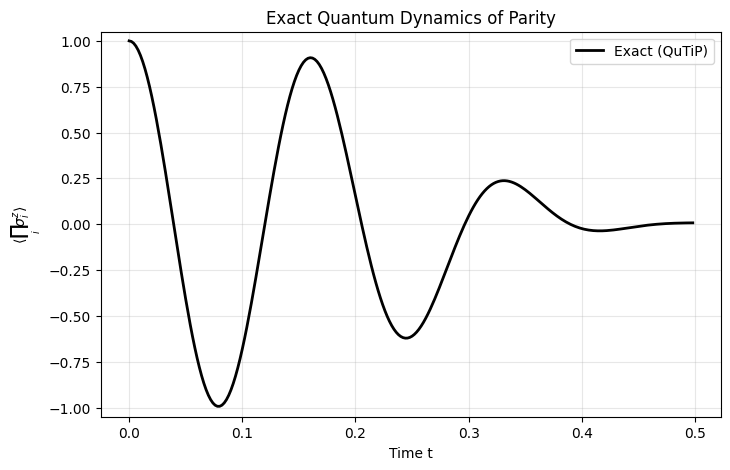

Initial parity: 1.000000
Final parity: 0.007461


In [126]:
import qutip as qt

var_path = f"./data/TFIM_{N}_parity/"
if N in [
    20,
]:
    times_exact = np.load(var_path + "times.npy")
    parity_exact = np.load(var_path + "parityZ.npy")
else:
    # Get the Hamiltonian matrix from netket
    H_matrix = hamiltonian.to_dense()

    # Convert to QuTiP Qobj
    H_qutip = qt.Qobj(H_matrix)

    # Get initial state from vstate
    psi0_array = vstate.to_array()
    psi0_qutip = qt.Qobj(psi0_array)
    psi0_qutip = psi0_qutip.unit()  # Normalize

    # Create parity operator (product of all Z_i)
    # Convert netket operator to matrix
    sigma_z_matrix = sigma_z.to_dense()

    # Convert to QuTiP
    Z_parity_qutip = qt.Qobj(sigma_z_matrix)

    # Time evolution parameters
    T = 0.5
    times_exact = np.linspace(0.0, T, 100)

    # Evolve the state and calculate expectation values
    parity_exact = []
    for t in times_exact:
        # Evolve state
        psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
        # Calculate expectation value
        par = qt.expect(Z_parity_qutip, psi_t)
        parity_exact.append(par)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(parity_exact), "k-", linewidth=2, label="Exact (QuTiP)")
plt.xlabel("Time t")
plt.ylabel(r"$\langle \prod_i \sigma^z_i \rangle$")
plt.title("Exact Quantum Dynamics of Parity")
plt.ylim([-1.05, 1.05])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial parity: {np.real(parity_exact[0]):.6f}")
print(f"Final parity: {np.real(parity_exact[-1]):.6f}")

In [113]:
def plot(save_path):
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    (ax_snr, ax_snrF, ax_dt) = axs[0]
    (ax_z, ax_ess, ax_rsq) = axs[1]
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"])
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")

    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    if ess_vals and q_vals:
        ax_right = ax_ess.twinx()
        (line1,) = ax_ess.plot(x_vals, ess_vals, color="tab:blue", label="ESS (bridge)")
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.1
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_ess.set_xlabel("Step")
        ax_ess.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        ax_ess.set_ylim(-0.05, 1.05)
        ax_right.set_ylim(0.0, 1.05)
        ax_ess.grid(True, alpha=0.3)
        ax_ess.set_title("Bridge ESS, q")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_ess.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("viridis")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / 20
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    # ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snr = plt.get_cmap('viridis')
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("viridis")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        # print(snr_F_data)
        frac = 0.0 if snrF_len <= 1 else i / 20
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    # ax_snrF.set_ylim([1e-2, 1e2])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])

    ax_dt.plot(x_vals, logger.data["dt"]["values"])
    ax_dt.set_xlabel("Step")
    ax_dt.set_ylabel("dt")
    ax_dt.set_title("Adaptive time step")
    ax_dt.set_yscale("log")
    ax_dt.set_ylim([1e-5, 1e-2])

    
    # Add cumulative r_squared on right axis
    t_vals = logger.data["t"]["values"]
    r_sq = logger.data["r_squared"]["values"]
    print(r_sq)
    ax_rsq.plot(t_vals, r_sq, color="tab:purple")
    ax_rsq.set_xlabel("t")
    ax_rsq.set_ylabel("r_squared", color="tab:purple")
    ax_rsq.set_title("Generator r_squared vs time")
    r_sq_arr = np.array(r_sq, dtype=float)
    if np.any(np.isfinite(r_sq_arr) & (r_sq_arr > 0.0)):
        ax_rsq.set_yscale("log")

    ax_rsq_right = ax_rsq.twinx()
    r_sq_arr = np.array(r_sq, dtype=float)
    r_sq_cum = np.nancumsum(r_sq_arr)
    ax_rsq_right.plot(
        t_vals, r_sq_cum, color="tab:green", label="cumulative r_squared"
    )
    ax_rsq_right.set_ylabel("cumulative r_squared", color="tab:green")
    ax_rsq_right.tick_params(axis="y")
    ax_rsq_right.set_yscale("log")

    plt.tight_layout()
    plt.show()

## Standard Dynamics

In [114]:
from schmitt_tdvp import TDVPSchmitt


def fit(n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"fixed_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    vstate.parameters = parity_parameters.copy()
    for i in range(100):
        vstate.sample()
    print(vstate.expect(sigma_z))
    callbacks = []
    callbacks.append(measure_parity)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmitt(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
        **tvmc_kwargs,
    )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [115]:
for n_samples_tvmc in n_samples_list:
    fit(n_samples_tvmc)


File not found
1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


100%|██████████| 0.50/0.50 [00:34<00:00, 68.0s/it, n=500, Generator=-0.09-0.06j ± 0.19 [σ²=1.8e+01]]


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 34.134                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.389 s                                                                           │
│ ├── (26.4%) | MCState.local_estimators : 9.010 s                                                                │
│ │   └── (59.6%) | MCState.sample : 5.373 s                                                                      │
│ │       └── (64.3%) | sampling n_discarded samples : 3.456 s                                                    │
│ ├── (4.9%) | QGTJacobian_DefaultConstructor : 1.661 s                                                           │
│ │   └── (52.0%) | jacobian : 0.864 s                                                                            │
│ └── (20.6%) | _impl : 7.047 s                                         

100%|██████████| 0.50/0.50 [00:28<00:00, 57.8s/it, n=500, Generator=-0.05-0.03j ± 0.15 [σ²=2.2e+01]]  


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 28.910                                                                                                   │
│ ├── (1.3%) | MCState.expect : 0.379 s                                                                           │
│ ├── (29.7%) | MCState.local_estimators : 8.579 s                                                                │
│ │   └── (60.5%) | MCState.sample : 5.194 s                                                                      │
│ │       └── (65.7%) | sampling n_discarded samples : 3.412 s                                                    │
│ ├── (4.6%) | QGTJacobian_DefaultConstructor : 1.336 s                                                           │
│ │   └── (46.0%) | jacobian : 0.614 s                                                                            │
│ └── (19.5%) | _impl : 5.634 s                                         

...

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 32.460                                                                                                   │
│ ├── (1.3%) | MCState.expect : 0.409 s                                                                           │
│ ├── (33.9%) | MCState.local_estimators : 11.010 s                                                               │
│ │   └── (56.4%) | MCState.sample : 6.215 s                                                                      │
│ │       └── (69.0%) | sampling n_discarded samples : 4.286 s                                                    │
│ ├── (4.6%) | QGTJacobian_DefaultConstructor : 1.486 s                                                           │
│ │   └── (52.0%) | jacobian : 0.773 s                                                                            │
│ └── (20.4%) | _impl : 6.608 s                                         

100%|██████████| 0.50/0.50 [00:50<00:00, 100s/it, n=500, Generator=-0.094+0.018j ± 0.053 [σ²=2.3e+01]] 


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 50.184                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.557 s                                                                           │
│ ├── (53.2%) | MCState.local_estimators : 26.704 s                                                               │
│ │   └── (73.5%) | MCState.sample : 19.614 s                                                                     │
│ │       └── (78.3%) | sampling n_discarded samples : 15.363 s                                                   │
│ ├── (3.7%) | QGTJacobian_DefaultConstructor : 1.849 s                                                           │
│ │   └── (57.4%) | jacobian : 1.061 s                                                                            │
│ └── (13.7%) | _impl : 6.862 s                                         

100%|██████████| 0.50/0.50 [01:22<00:00, 165s/it, n=500, Generator=-0.058-0.010j ± 0.038 [σ²=2.4e+01]]


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 82.296                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.871 s                                                                           │
│ ├── (59.3%) | MCState.local_estimators : 48.830 s                                                               │
│ │   └── (73.2%) | MCState.sample : 35.732 s                                                                     │
│ │       └── (77.8%) | sampling n_discarded samples : 27.782 s                                                   │
│ ├── (3.8%) | QGTJacobian_DefaultConstructor : 3.119 s                                                           │
│ │   └── (59.9%) | jacobian : 1.867 s                                                                            │
│ └── (12.1%) | _impl : 9.953 s                                         

Restored: True
[array(nan), array(1.19728031e-15), array(1.77328426e-15), array(1.61982988e-15), array(1.89132362e-15), array(1.47004803e-15), array(1.59566099e-15), array(1.11425251e-15), array(1.6417106e-15), array(2.21653397e-14), array(1.43313202e-15), array(1.57314768e-15), array(1.85938309e-15), array(1.37185263e-15), array(1.32961698e-15), array(1.96890198e-15), array(1.78709619e-15), array(1.57294816e-15), array(1.95517489e-15), array(1.41151171e-15), array(6.87565015e-15), array(1.42909754e-15), array(1.12882048e-14), array(5.24939211e-15), array(1.34531738e-15), array(3.3037395e-15), array(7.55103655e-13), array(1.35180951e-15), array(1.7598746e-15), array(1.52811805e-15), array(1.39881507e-15), array(1.42050496e-15), array(1.42673419e-15), array(1.59732219e-15), array(1.57279646e-15), array(1.51317159e-15), array(1.45664359e-15), array(5.71869086e-14), array(1.58946499e-15), array(2.86666573e-13), array(1.79859712e-15), array(4.42229407e-15), array(7.36535239e-14), array(1.7

/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_497760/2194358539.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


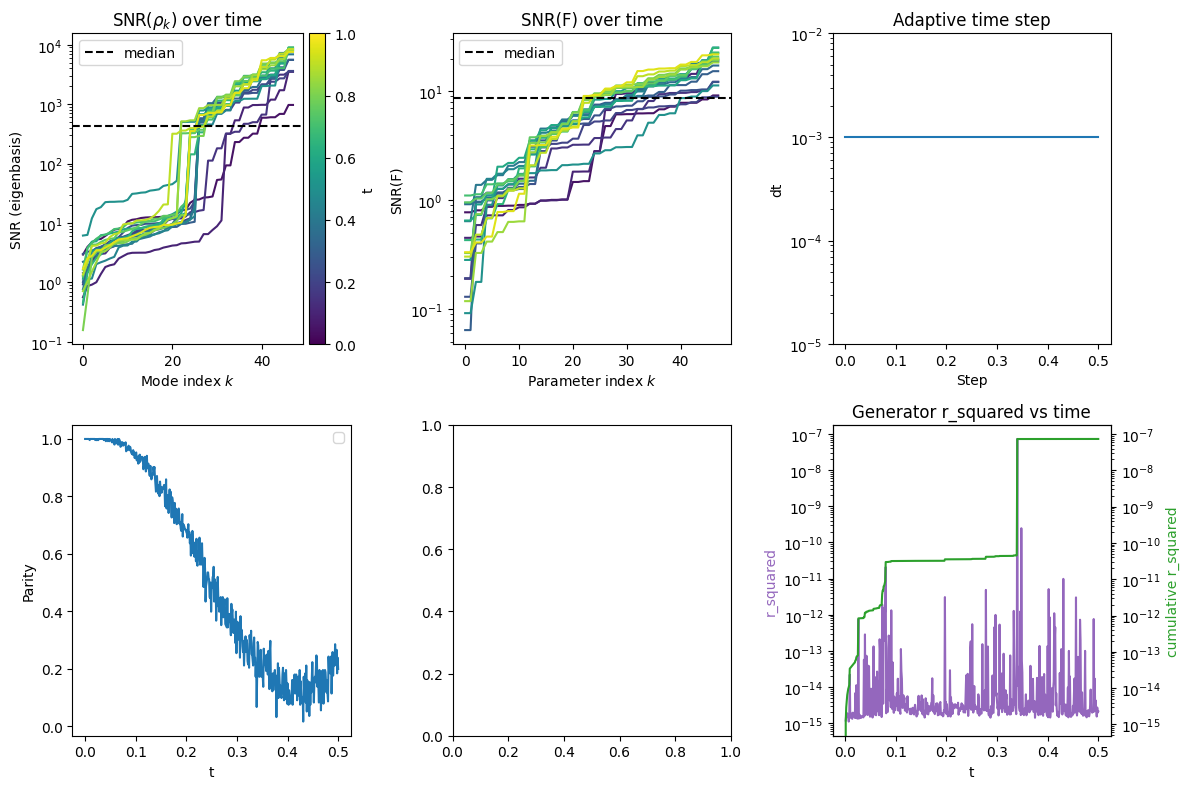

Restored: True
Restored: True
Restored: True
Restored: True
Restored: True
Restored: True


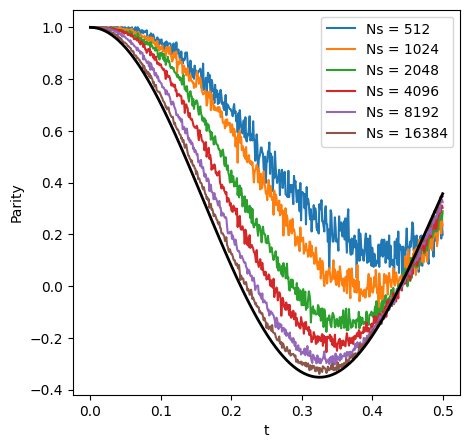

In [116]:
n_samples_tvmc = 2**9
exp_name = f"fixed_{n_samples_tvmc}/"
save_path = f"./data/TFIM_{N}_parity/{exp_name}"
plot(save_path)

fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"fixed_{n_samples}"
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"], label = f"Ns = {n_samples}")
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")
ax_z.plot(times_exact, np.real(parity_exact), 'k-', linewidth=2, label='Exact')



In [155]:
from schmitt_tdvp_bridge import TDVPSchmittBridge

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 40)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate = get_vstate(n_samples_tvmc)
    vstate.parameters = parity_parameters.copy()
    for i in range(1000):
        vstate.sample()
    
    callbacks = [ ]
    callbacks.append(measure_parity)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    integrator = RK45(1e-4, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.2,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [ ]:
fit_bridge(2**10)

File not found


  0%|          | 0.00/0.50 [00:00<?, ?it/s, n=0, Generator=None]

Saved parameters...


  2%|▏         | 0.01/0.50 [00:37<26:43, 3.28ks/it, n=114, Generator=-0.63+22.69j ± 0.67 [σ²=4.7e+02]]

Restored: True
[array(nan), array(1.35961133e-07), array(1.48970782e-07), array(1.77363558e-07), array(1.60494855e-07), array(1.65150181e-07), array(1.890124e-07), array(1.58083355e-07), array(2.03853772e-07), array(2.06560645e-07), array(2.46008479e-07), array(2.2096661e-07), array(2.05112213e-07), array(2.60451146e-07), array(1.87765766e-07), array(2.27275023e-07), array(2.13791331e-07), array(1.68645987e-07), array(2.2139575e-07), array(2.19702385e-07), array(1.14320038e-07), array(5.98750777e-08), array(9.51517407e-08), array(9.34159838e-08), array(1.40697312e-07), array(5.66603099e-07), array(9.75648974e-08), array(1.22507386e-07), array(4.81218981e-08), array(1.04326208e-07), array(1.2882338e-07), array(1.09644346e-07), array(5.60998839e-08), array(6.37758779e-08), array(1.36356091e-07), array(6.63084937e-08), array(1.43411138e-07), array(8.87405775e-08), array(1.2552792e-07), array(1.10256713e-07), array(7.07248152e-08), array(1.13696491e-07), array(7.79180201e-08), array(7.1331

/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_497760/2194358539.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


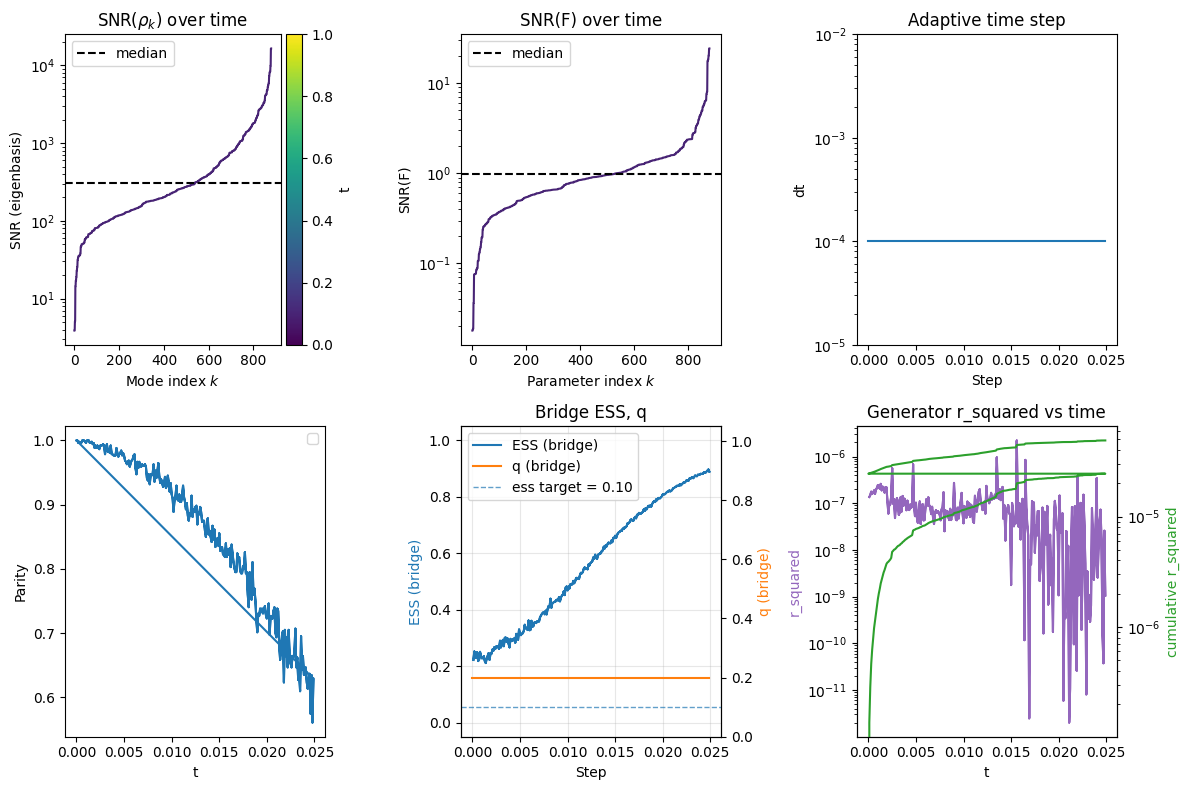

File not found
Restored: False
Restored: True
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


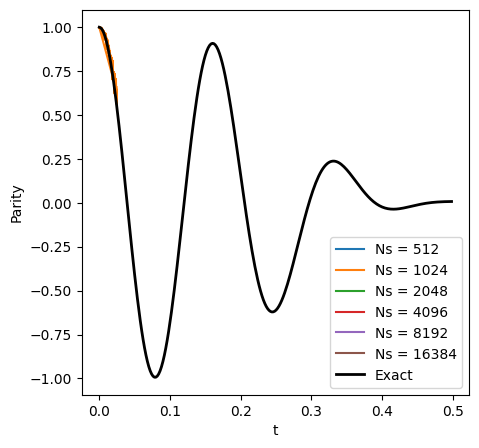

In [154]:
n_samples_tvmc = 2**10
exp_name = f"bridge_{n_samples_tvmc}/"
save_path = f"./data/TFIM_{N}_parity/{exp_name}"
plot(save_path)

fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())    
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"], label = f"Ns = {n_samples}", zorder=-1)
    ax_z.set_xlabel("t")
    ax_z.set_ylabel(r"Parity")
ax_z.plot(times_exact, np.real(parity_exact), 'k-', linewidth=2, label='Exact')
ax_z.legend()
plt.show()
